<a href="https://colab.research.google.com/github/Sweetata/smartflow/blob/main/analise_smartflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

nome_arquivo = list(uploaded.keys())[0]  # pega o nome real do arquivo que você enviou, seja qual for
df = pd.read_excel(nome_arquivo, sheet_name='production')
df.head()
ritmo_medio = df['actual_rate_kits_min'].mean()
print(ritmo_medio)
producao_total = df['quantity_produced'].sum()
print(producao_total)

Saving smartflow (3).xlsx to smartflow (3).xlsx
4.357001723771832
4790


In [3]:
producao_por_funcionario = df.groupby('employee_id')['quantity_produced'].sum()
print(producao_por_funcionario)

employee_id
F001    415
F002    415
F003    490
F004    455
F005    590
F006    415
F007    505
F008    430
F009    610
F010    465
Name: quantity_produced, dtype: int64


In [4]:
ritmo_por_funcionario = df.groupby('employee_id')['actual_rate_kits_min'].mean()
print(ritmo_por_funcionario)

employee_id
F001    3.915598
F002    3.809764
F003    4.337406
F004    4.174242
F005    5.314935
F006    3.808081
F007    4.429825
F008    4.019043
F009    5.495130
F010    4.265993
Name: actual_rate_kits_min, dtype: float64


In [5]:
funcionarios = pd.read_excel(nome_arquivo, sheet_name='employees')
funcionarios.head()

,employee_id,employee_name,table_id,reference_capacity_kits_min,scheduled_hours
0,F001,Funcionário 01,M01,4.0,8
1,F002,Funcionário 02,M01,4.0,8
2,F003,Funcionário 03,M01,5.0,8
3,F004,Funcionário 04,M01,4.5,8
4,F005,Funcionário 05,M01,6.0,8


In [6]:
# primeiro, transformamos aquele resultado do groupby numa tabela de verdade
ritmo_df = ritmo_por_funcionario.reset_index()

# agora juntamos com a tabela de funcionários, casando pelo employee_id
comparacao = ritmo_df.merge(funcionarios, on='employee_id')

# e calculamos o % da meta, igual ao achievement_pct do seu dashboard
comparacao['achievement_pct'] = comparacao['actual_rate_kits_min'] / comparacao['reference_capacity_kits_min']

comparacao

,employee_id,actual_rate_kits_min,employee_name,table_id,reference_capacity_kits_min,scheduled_hours,achievement_pct
0,F001,3.915598,Funcionário 01,M01,4.0,8,0.978900
1,F002,3.809764,Funcionário 02,M01,4.0,8,0.952441
2,F003,4.337406,Funcionário 03,M01,5.0,8,0.867481
3,F004,4.174242,Funcionário 04,M01,4.5,8,0.927609
4,F005,5.314935,Funcionário 05,M01,6.0,8,0.885823
5,F006,3.808081,Funcionário 06,M02,4.0,8,0.952020
6,F007,4.429825,Funcionário 07,M02,5.0,8,0.885965
7,F008,4.019043,Funcionário 08,M02,4.0,8,1.004761
8,F009,5.495130,Funcionário 09,M02,6.0,8,0.915855
9,F010,4.265993,Funcionário 10,M02,4.5,8,0.947999


In [7]:
def classificar(pct):
    if pct > 1.15:
        return "ALTO"
    elif pct > 1.05:
        return "ATENÇÃO"
    else:
        return "NORMAL"

comparacao['status'] = comparacao['achievement_pct'].apply(classificar)
comparacao

,employee_id,actual_rate_kits_min,employee_name,table_id,reference_capacity_kits_min,scheduled_hours,achievement_pct,status
0,F001,3.915598,Funcionário 01,M01,4.0,8,0.978900,NORMAL
1,F002,3.809764,Funcionário 02,M01,4.0,8,0.952441,NORMAL
2,F003,4.337406,Funcionário 03,M01,5.0,8,0.867481,NORMAL
3,F004,4.174242,Funcionário 04,M01,4.5,8,0.927609,NORMAL
4,F005,5.314935,Funcionário 05,M01,6.0,8,0.885823,NORMAL
5,F006,3.808081,Funcionário 06,M02,4.0,8,0.952020,NORMAL
6,F007,4.429825,Funcionário 07,M02,5.0,8,0.885965,NORMAL
7,F008,4.019043,Funcionário 08,M02,4.0,8,1.004761,NORMAL
8,F009,5.495130,Funcionário 09,M02,6.0,8,0.915855,NORMAL
9,F010,4.265993,Funcionário 10,M02,4.5,8,0.947999,NORMAL


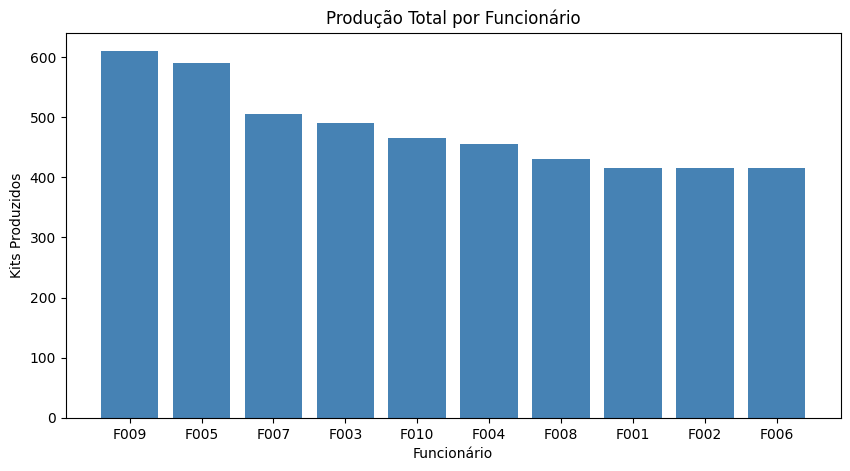

In [8]:
import matplotlib.pyplot as plt

producao_por_funcionario = producao_por_funcionario.sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(producao_por_funcionario.index, producao_por_funcionario.values, color='steelblue')
plt.title('Produção Total por Funcionário')
plt.xlabel('Funcionário')
plt.ylabel('Kits Produzidos')
plt.show()

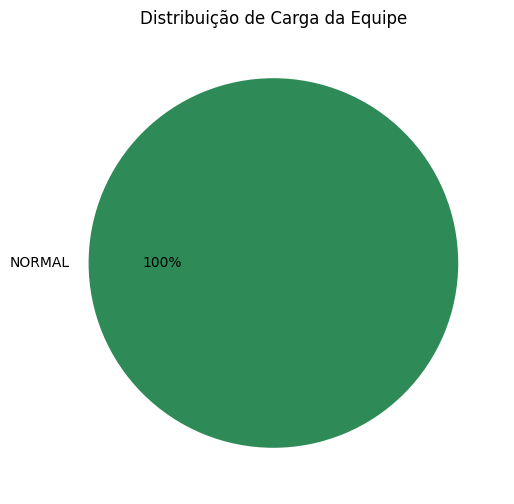

In [9]:
contagem_status = comparacao['status'].value_counts()

cores = {'NORMAL': 'seagreen', 'ATENÇÃO': 'goldenrod', 'ALTO': 'firebrick'}
cores_ordenadas = [cores[status] for status in contagem_status.index]

plt.figure(figsize=(6, 6))
plt.pie(contagem_status.values, labels=contagem_status.index, autopct='%1.0f%%', colors=cores_ordenadas)
plt.title('Distribuição de Carga da Equipe')
plt.show()

In [10]:
import sqlite3

# cria um banco de dados na memória e salva nossas tabelas nele
conexao = sqlite3.connect('smartflow.db')
df.to_sql('production', conexao, if_exists='replace', index=False)
funcionarios.to_sql('employees', conexao, if_exists='replace', index=False)

print("Banco de dados criado com sucesso!")

Banco de dados criado com sucesso!


In [11]:
consulta = """
SELECT employee_id, SUM(quantity_produced) AS total_produzido
FROM production
GROUP BY employee_id
ORDER BY total_produzido DESC
"""

resultado = pd.read_sql(consulta, conexao)
resultado

,employee_id,total_produzido
0,F009,610
1,F005,590
2,F007,505
3,F003,490
4,F010,465
5,F004,455
6,F008,430
7,F006,415
8,F002,415
9,F001,415


In [12]:
consulta2 = """
SELECT p.employee_id, e.employee_name, AVG(p.actual_rate_kits_min) AS ritmo_medio, e.reference_capacity_kits_min AS meta
FROM production p
JOIN employees e ON p.employee_id = e.employee_id
GROUP BY p.employee_id
ORDER BY ritmo_medio DESC
"""

resultado2 = pd.read_sql(consulta2, conexao)
resultado2

,employee_id,employee_name,ritmo_medio,meta
0,F009,Funcionário 09,5.495130,6.0
1,F005,Funcionário 05,5.314935,6.0
2,F007,Funcionário 07,4.429825,5.0
3,F003,Funcionário 03,4.337406,5.0
4,F010,Funcionário 10,4.265993,4.5
5,F004,Funcionário 04,4.174242,4.5
6,F008,Funcionário 08,4.019043,4.0
7,F001,Funcionário 01,3.915598,4.0
8,F002,Funcionário 02,3.809764,4.0
9,F006,Funcionário 06,3.808081,4.0


In [13]:
consulta3 = """
SELECT p.employee_id, e.employee_name, AVG(p.actual_rate_kits_min) AS ritmo_medio, e.reference_capacity_kits_min AS meta
FROM production p
JOIN employees e ON p.employee_id = e.employee_id
GROUP BY p.employee_id
HAVING ritmo_medio > meta
ORDER BY ritmo_medio DESC
"""

resultado3 = pd.read_sql(consulta3, conexao)
resultado3

,employee_id,employee_name,ritmo_medio,meta
0,F008,Funcionário 08,4.019043,4.0
